In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
n = 200

size     = np.random.randint(500, 3500, n).astype(float)
location = np.random.randint(0, 3, n).astype(float)   # 0=suburban, 1=urban, 2=downtown
rooms    = np.random.randint(1, 7, n).astype(float)

price = (150 * size
       + 20000 * location
       + 10000 * rooms
       + np.random.normal(0, 15000, n))

X = np.column_stack([size, location, rooms])
y = price

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):,.0f}")
print(f"Test  MSE: {mean_squared_error(y_test,  y_test_pred):,.0f}")
print(f"Train R²:  {r2_score(y_train, y_train_pred):.4f}")
print(f"Test  R²:  {r2_score(y_test,  y_test_pred):.4f}")

Train MSE: 251,472,702
Test  MSE: 258,196,080
Train R²:  0.9835
Test  R²:  0.9825


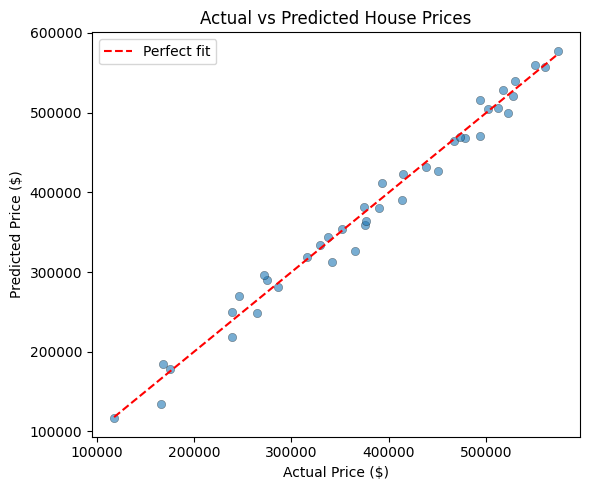

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', label='Perfect fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()